In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

from catboost import CatBoostRegressor

In [2]:
df = pd.read_csv("Cars_Data.csv")
df.head()

,price,brand,model,color,registration_date,power_kw,power_ps,transmission_type,fuel_type,fuel_consumption_l_100km.1,mileage_in_km
0,2013796,ford,Kuga,black,01-05-23,140,190,Automatic,Hybrid,5.4,100
1,604557,hyundai,i10,black,01-09-18,49,67,Manual,Petrol,4.6,27782
2,1281316,honda,CR-V,red,01-07-18,114,155,Automatic,Petrol,7.5,57000
3,1830676,kia,Sportage,black,01-02-23,110,150,Manual,Petrol,5.9,7500
4,303456,honda,Civic,black,01-09-09,103,140,Manual,Petrol,6.7,160000


In [3]:
df["transmission_type"].value_counts(normalize=True) * 100

transmission_type
Automatic         52.211517
Manual            47.230903
Unknown            0.434394
Semi-automatic     0.123186
Name: proportion, dtype: float64

In [4]:
df["transmission_unknown_flag"] = (df["transmission_type"] == "Unknown").astype(int)

In [5]:
df.shape

(77119, 12)

In [6]:
df = df.drop_duplicates()
df.shape

(74445, 12)

In [7]:
df["registration_date"] = pd.to_datetime(
    df["registration_date"],
    format="%d-%m-%y",
    errors="coerce"
)

current_year = datetime.now().year
df["vehicle_age"] = current_year - df["registration_date"].dt.year

df = df.drop(columns=["registration_date"])
df["vehicle_age"].describe()

count    74445.000000
mean         9.449204
std          4.926856
min          3.000000
25%          6.000000
50%          8.000000
75%         12.000000
max         31.000000
Name: vehicle_age, dtype: float64

In [8]:
df = df[df["mileage_in_km"] > 0]
df = df[df["vehicle_age"] >= 0]
df.shape

(74364, 12)

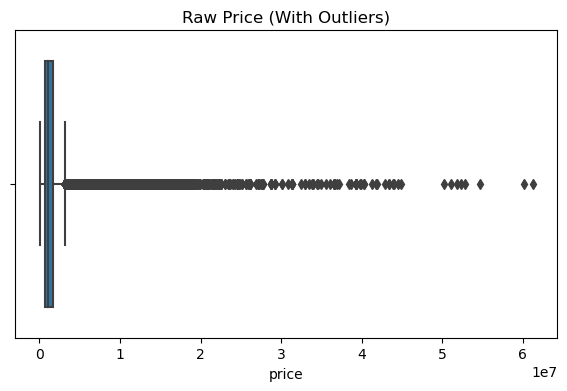

In [9]:
plt.figure(figsize=(7,4))
sns.boxplot(x=df["price"])
plt.title("Raw Price (With Outliers)")
plt.show()

In [10]:
price_low = df["price"].quantile(0.01)
price_high = df["price"].quantile(0.99)

df["price"] = df["price"].clip(price_low, price_high)

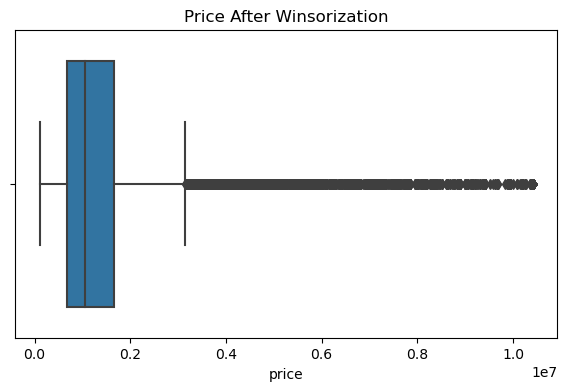

In [11]:
plt.figure(figsize=(7,4))
sns.boxplot(x=df["price"])
plt.title("Price After Winsorization")
plt.show()

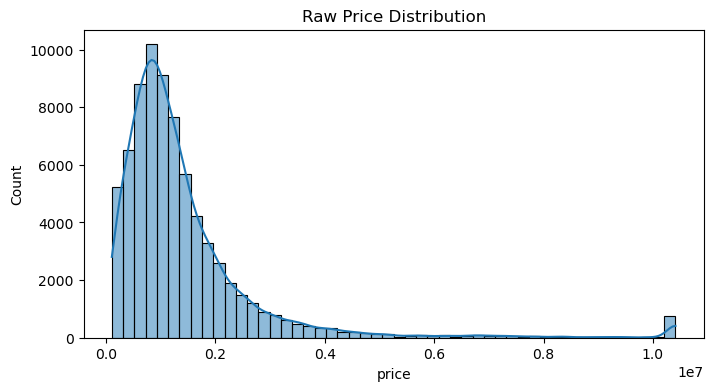

In [12]:
plt.figure(figsize=(8,4))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Raw Price Distribution")
plt.show()

In [13]:
df["log_price"] = np.log1p(df["price"])

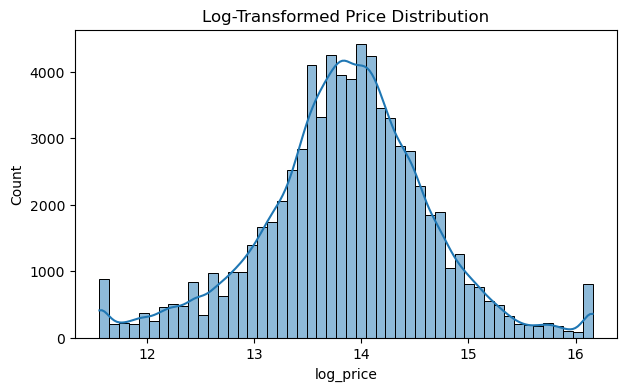

In [14]:
plt.figure(figsize=(7,4))
sns.histplot(df["log_price"], bins=50, kde=True)
plt.title("Log-Transformed Price Distribution")
plt.show()

In [15]:
df["km_per_year"] = df["mileage_in_km"] / (df["vehicle_age"] + 1)
df["log_mileage"] = np.log1p(df["mileage_in_km"])

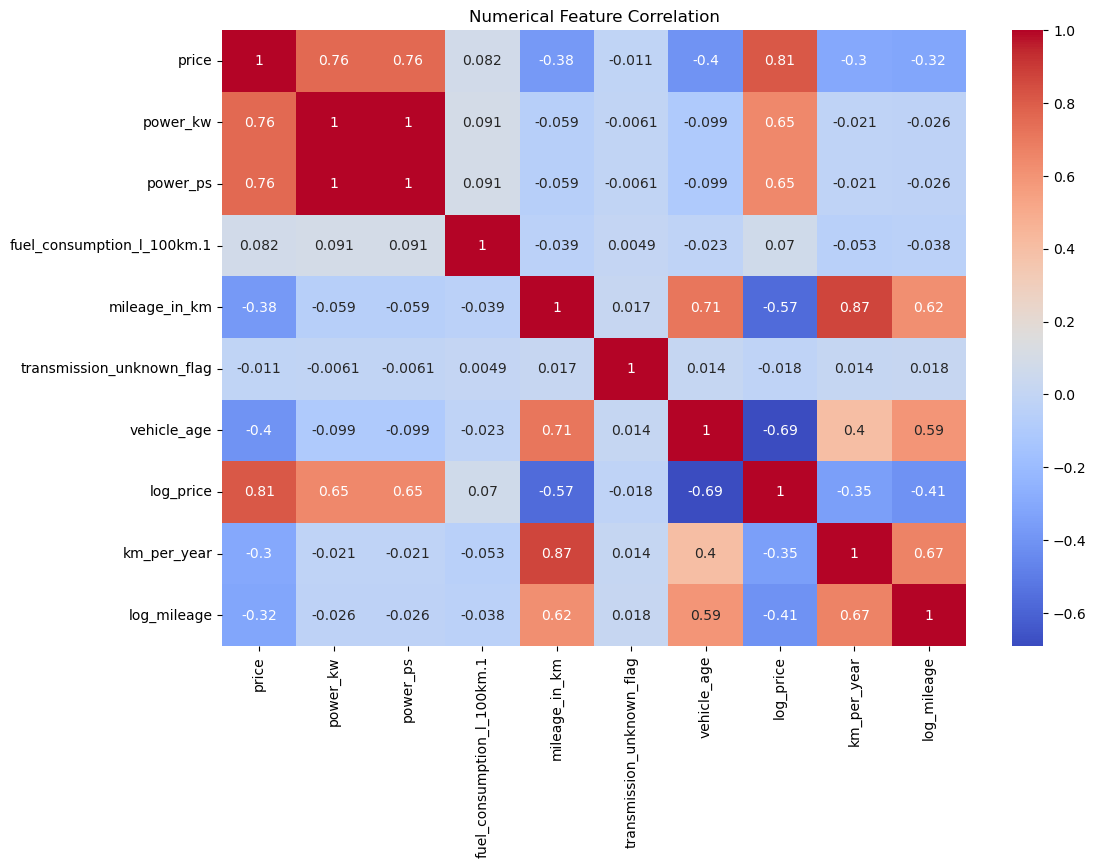

In [16]:
num_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(),annot=True, cmap="coolwarm")
plt.title("Numerical Feature Correlation")
plt.show()

In [17]:
df = df.drop("power_ps" , axis=1)

In [18]:
target = "log_price"

cat_features = [
    "brand",
    "model",
    "color",
    "transmission_type",
    "fuel_type"
]

features = [c for c in df.columns if c not in ["price", "log_price"]]

X = df[features]
y = df[target]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
model = CatBoostRegressor(
    iterations=3000,
    depth=10,
    learning_rate=0.03,
    loss_function="RMSE",
    eval_metric="R2",
    random_strength=10,
    bagging_temperature=1,
    l2_leaf_reg=3,
    verbose=200,
    random_seed=42
)

In [21]:
model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    use_best_model=True
)

0:	learn: 0.0311775	test: 0.0310195	best: 0.0310195 (0)	total: 185ms	remaining: 9m 13s
200:	learn: 0.9135132	test: 0.9133358	best: 0.9133358 (200)	total: 24.7s	remaining: 5m 44s
400:	learn: 0.9262413	test: 0.9246019	best: 0.9246019 (400)	total: 50.2s	remaining: 5m 25s
600:	learn: 0.9374452	test: 0.9321804	best: 0.9321804 (600)	total: 1m 21s	remaining: 5m 23s
800:	learn: 0.9423529	test: 0.9339011	best: 0.9339011 (800)	total: 1m 50s	remaining: 5m 3s
1000:	learn: 0.9455930	test: 0.9348077	best: 0.9348077 (1000)	total: 2m 23s	remaining: 4m 46s
1200:	learn: 0.9482688	test: 0.9353332	best: 0.9353332 (1200)	total: 2m 55s	remaining: 4m 23s
1400:	learn: 0.9505310	test: 0.9356410	best: 0.9356410 (1400)	total: 3m 28s	remaining: 3m 58s
1600:	learn: 0.9524733	test: 0.9358367	best: 0.9358367 (1600)	total: 3m 59s	remaining: 3m 29s
1800:	learn: 0.9541335	test: 0.9359697	best: 0.9359697 (1800)	total: 4m 25s	remaining: 2m 56s
2000:	learn: 0.9557448	test: 0.9360550	best: 0.9360646 (1992)	total: 4m 50s	re

In [22]:
y_pred_log = model.predict(X_test)

r2 = r2_score(y_test, y_pred_log)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_log))

r2, rmse

(0.936227217502994, 0.2007498603061906)

In [23]:
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

r2_real = r2_score(y_test_real, y_pred_real)
rmse_real = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

r2_real, rmse_real

(0.941953809298433, 337443.14658487885)

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions are already in log-space
# Convert back to real price scale
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

# Metrics
mae = mean_absolute_error(y_test_real, y_pred_real)
mse = mean_squared_error(y_test_real, y_pred_real)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_real, y_pred_real)

print("📊 Final Model Evaluation (Original Price Scale)")
print("-" * 50)
print(f"MAE  (Mean Absolute Error): {mae:,.2f}")
print(f"MSE  (Mean Squared Error):  {mse:,.2f}")
print(f"RMSE (Root MSE):           {rmse:,.2f}")
print(f"R²   (R-squared):          {r2:.4f}")

📊 Final Model Evaluation (Original Price Scale)
--------------------------------------------------
MAE  (Mean Absolute Error): 160,206.33
MSE  (Mean Squared Error):  113,867,877,177.10
RMSE (Root MSE):           337,443.15
R²   (R-squared):          0.9420


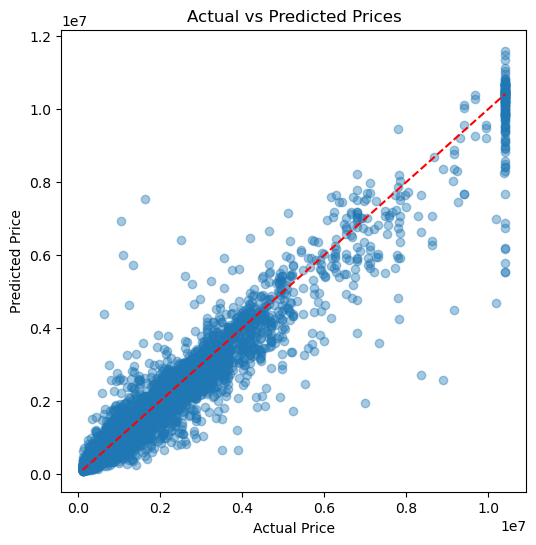

In [25]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_real, y_pred_real, alpha=0.4)
plt.plot(
    [y_test_real.min(), y_test_real.max()],
    [y_test_real.min(), y_test_real.max()],
    "--r"
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

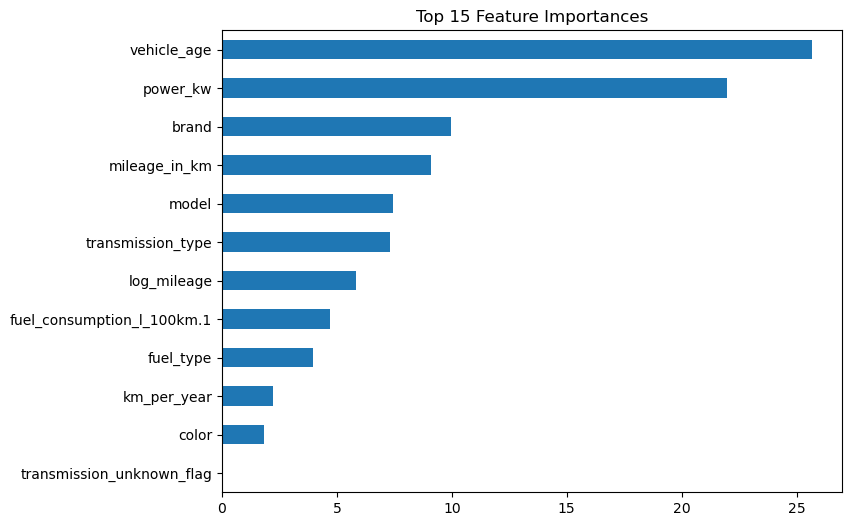

In [26]:
importances = model.get_feature_importance()
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(8,6))
feat_imp.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances")
plt.show()